# Music Genre Classification — Data Analysis
Full exploratory and model analysis on the GTZAN feature dataset.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.cluster import KMeans
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

## 2. Load Dataset

In [3]:
df = pd.read_csv('music_5sec_features.csv')

print('Shape:', df.shape)
print('Genres:', sorted(df['label'].unique()))
df.head()

Shape: (5985, 65)
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


,track_id,mfcc_1_mean,mfcc_1_var,mfcc_2_mean,mfcc_2_var,mfcc_3_mean,mfcc_3_var,mfcc_4_mean,mfcc_4_var,mfcc_5_mean,...,rolloff_mean,rolloff_var,flatness_mean,flatness_var,zcr_mean,zcr_var,rms_mean,rms_var,tempo,label
0,1,-119.217600,2274.5337,124.338330,251.25555,-22.838790,328.88797,42.07474,158.041280,-7.011255,...,3745.481364,9.667655e+05,0.004447,0.000036,0.083953,0.000825,0.124171,0.002805,123.046875,blues
1,1,-131.973660,3024.8772,116.727630,205.12883,-14.334999,158.68523,48.22651,200.175080,-4.449632,...,3949.947103,6.724590e+05,0.003909,0.000014,0.075758,0.000580,0.124230,0.003497,123.046875,blues
2,1,-109.010670,2448.1730,134.205020,296.46460,-19.396326,156.30157,40.78598,118.761720,-13.618481,...,3488.927205,7.501875e+05,0.003425,0.000010,0.069698,0.000297,0.141030,0.002071,123.046875,blues
3,1,-102.702530,2601.4660,113.554344,399.55685,-16.050467,189.84277,43.88332,146.786790,-10.231324,...,4313.170369,1.146375e+06,0.007680,0.000082,0.092857,0.001245,0.128789,0.003560,129.199219,blues
4,1,-107.959145,2039.5167,125.162780,237.26869,-20.689390,275.86188,41.46085,114.088264,-11.114463,...,3813.171387,8.246002e+05,0.004225,0.000030,0.073932,0.000296,0.140579,0.002559,123.046875,blues


## 3. Class Distribution

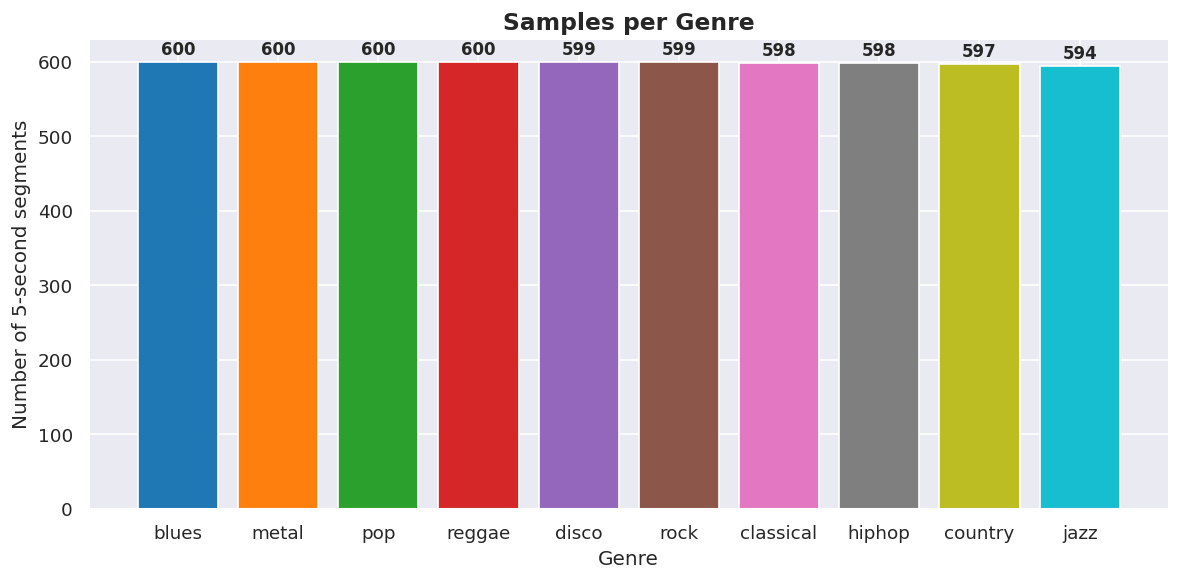

In [4]:
counts = df['label'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values,
              color=sns.color_palette('tab10', len(counts)))

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Samples per Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of 5-second segments')
plt.tight_layout()
plt.savefig('plot_class_distribution.png', dpi=150)
plt.show()

## 4. Feature Overview

In [5]:
feature_cols = [c for c in df.columns if c not in ['label', 'track_id']]
print(f'Total features: {len(feature_cols)}')
df[feature_cols].describe().round(3)

Total features: 63


,mfcc_1_mean,mfcc_1_var,mfcc_2_mean,mfcc_2_var,mfcc_3_mean,mfcc_3_var,mfcc_4_mean,mfcc_4_var,mfcc_5_mean,mfcc_5_var,...,bandwidth_var,rolloff_mean,rolloff_var,flatness_mean,flatness_var,zcr_mean,zcr_var,rms_mean,rms_var,tempo
count,5985.000,5985.000,5985.000,5985.000,5985.000,5985.000,5985.000,5985.000,5985.000,5985.000,...,5985.000,5985.000,5.985000e+03,5985.000,5985.000,5985.000,5985.000,5985.000,5985.000,5985.000
mean,-145.464,3035.261,100.597,622.711,-9.748,399.432,37.009,195.500,-1.807,153.421,...,123654.802,4571.061,1.692611e+06,0.022,0.001,0.103,0.003,0.130,0.003,122.300
std,105.060,2687.377,33.753,460.992,23.366,295.214,17.428,128.671,13.163,107.719,...,101373.929,1620.175,1.469645e+06,0.031,0.004,0.044,0.003,0.068,0.004,30.685
min,-641.845,46.556,-7.652,8.196,-99.639,3.394,-29.343,3.960,-45.274,9.175,...,1387.155,675.156,1.287241e+03,0.000,0.000,0.013,0.000,0.001,0.000,33.128
25%,-202.184,1319.409,76.215,302.102,-25.863,198.581,24.512,101.849,-11.172,77.173,...,54175.107,3374.532,6.371199e+05,0.003,0.000,0.068,0.001,0.084,0.001,99.384
50%,-120.870,2351.662,98.247,506.658,-11.477,325.863,37.685,164.773,-1.128,126.282,...,97300.397,4647.085,1.248850e+06,0.010,0.000,0.098,0.002,0.121,0.002,117.454
75%,-70.462,3980.816,121.461,816.364,5.699,517.110,49.373,258.469,7.936,200.381,...,163053.209,5576.801,2.346476e+06,0.029,0.001,0.133,0.003,0.175,0.003,135.999
max,107.242,45035.527,246.099,5518.538,72.284,3431.456,84.717,1478.812,39.775,1558.532,...,1856220.621,9478.946,1.200966e+07,0.556,0.231,0.322,0.049,0.432,0.030,258.398


## 5. Feature Distributions by Genre (Key Features)

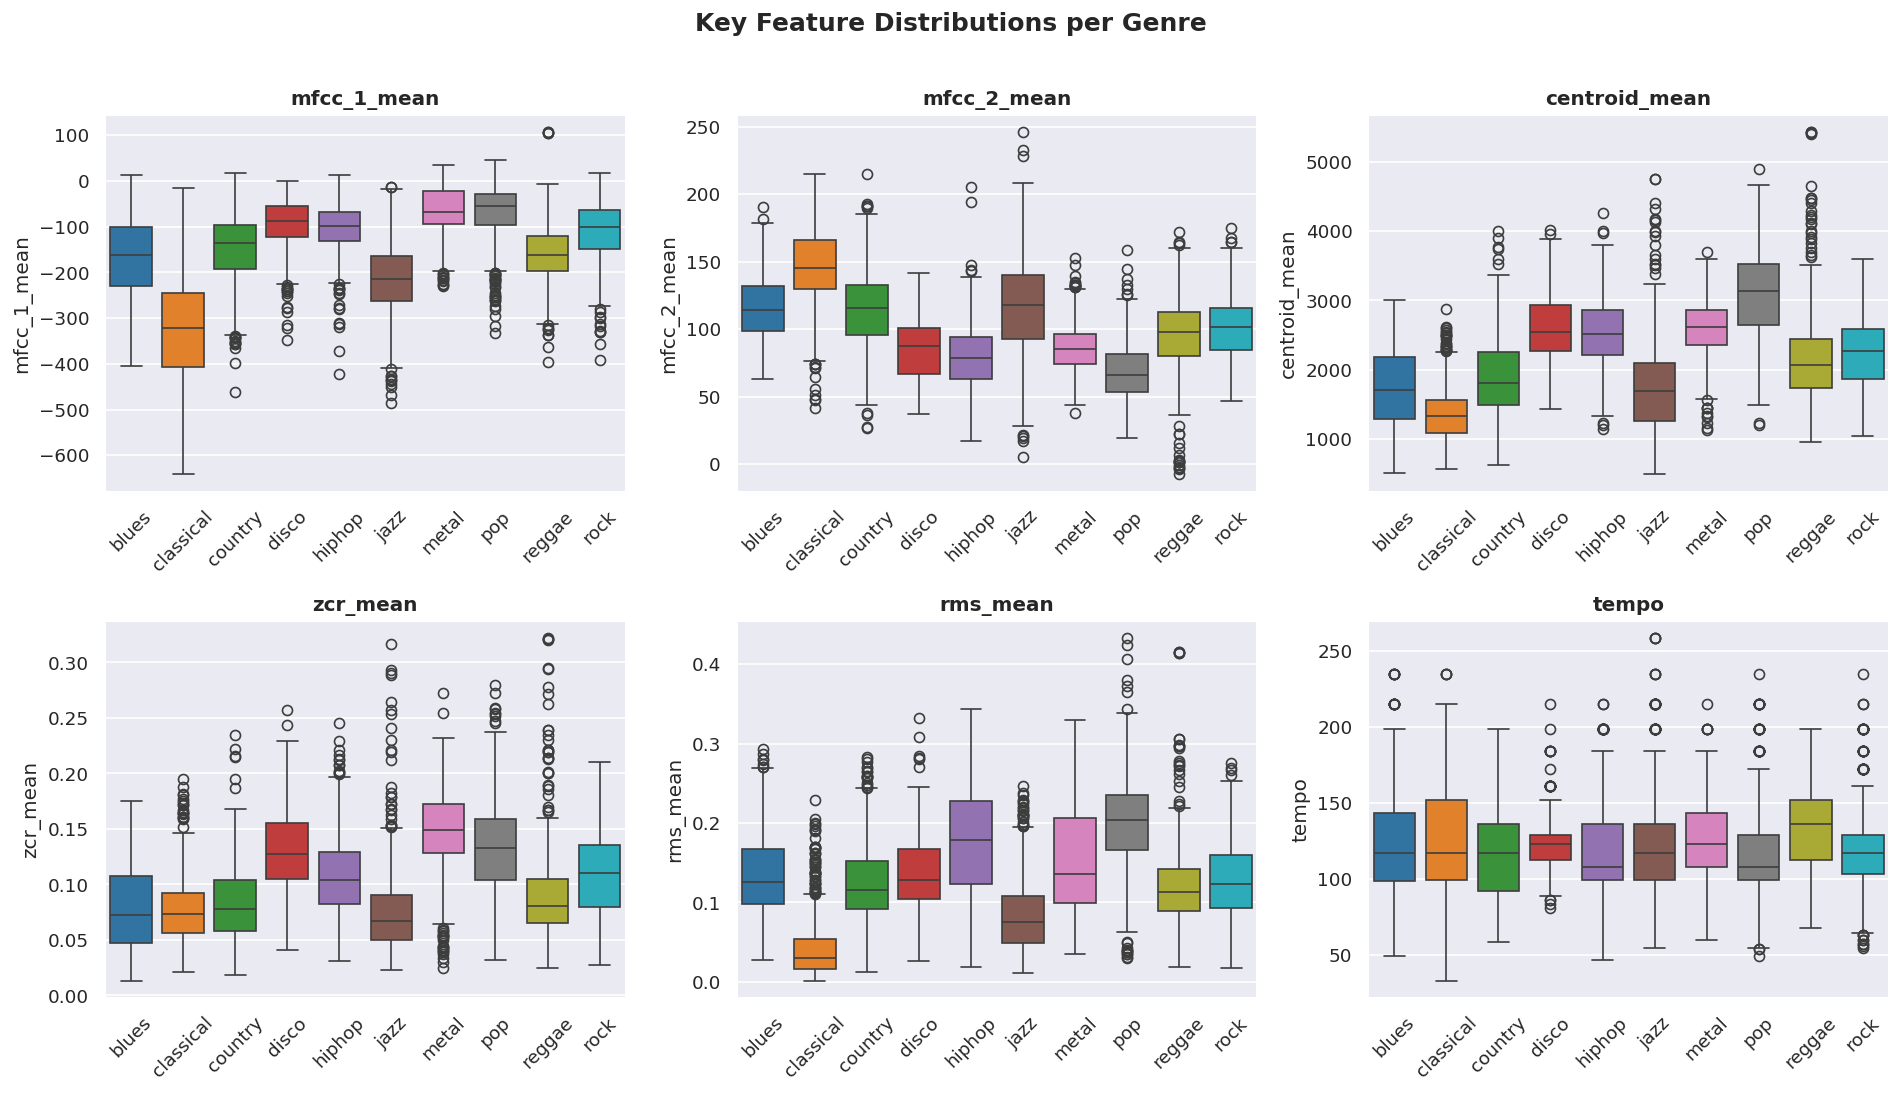

In [6]:
key_features = ['mfcc_1_mean', 'mfcc_2_mean', 'centroid_mean', 'zcr_mean', 'rms_mean', 'tempo']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.boxplot(
        data=df, x='label', y=feat, ax=axes[i],
        palette='tab10', order=sorted(df['label'].unique())
    )
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Key Feature Distributions per Genre', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation Heatmap

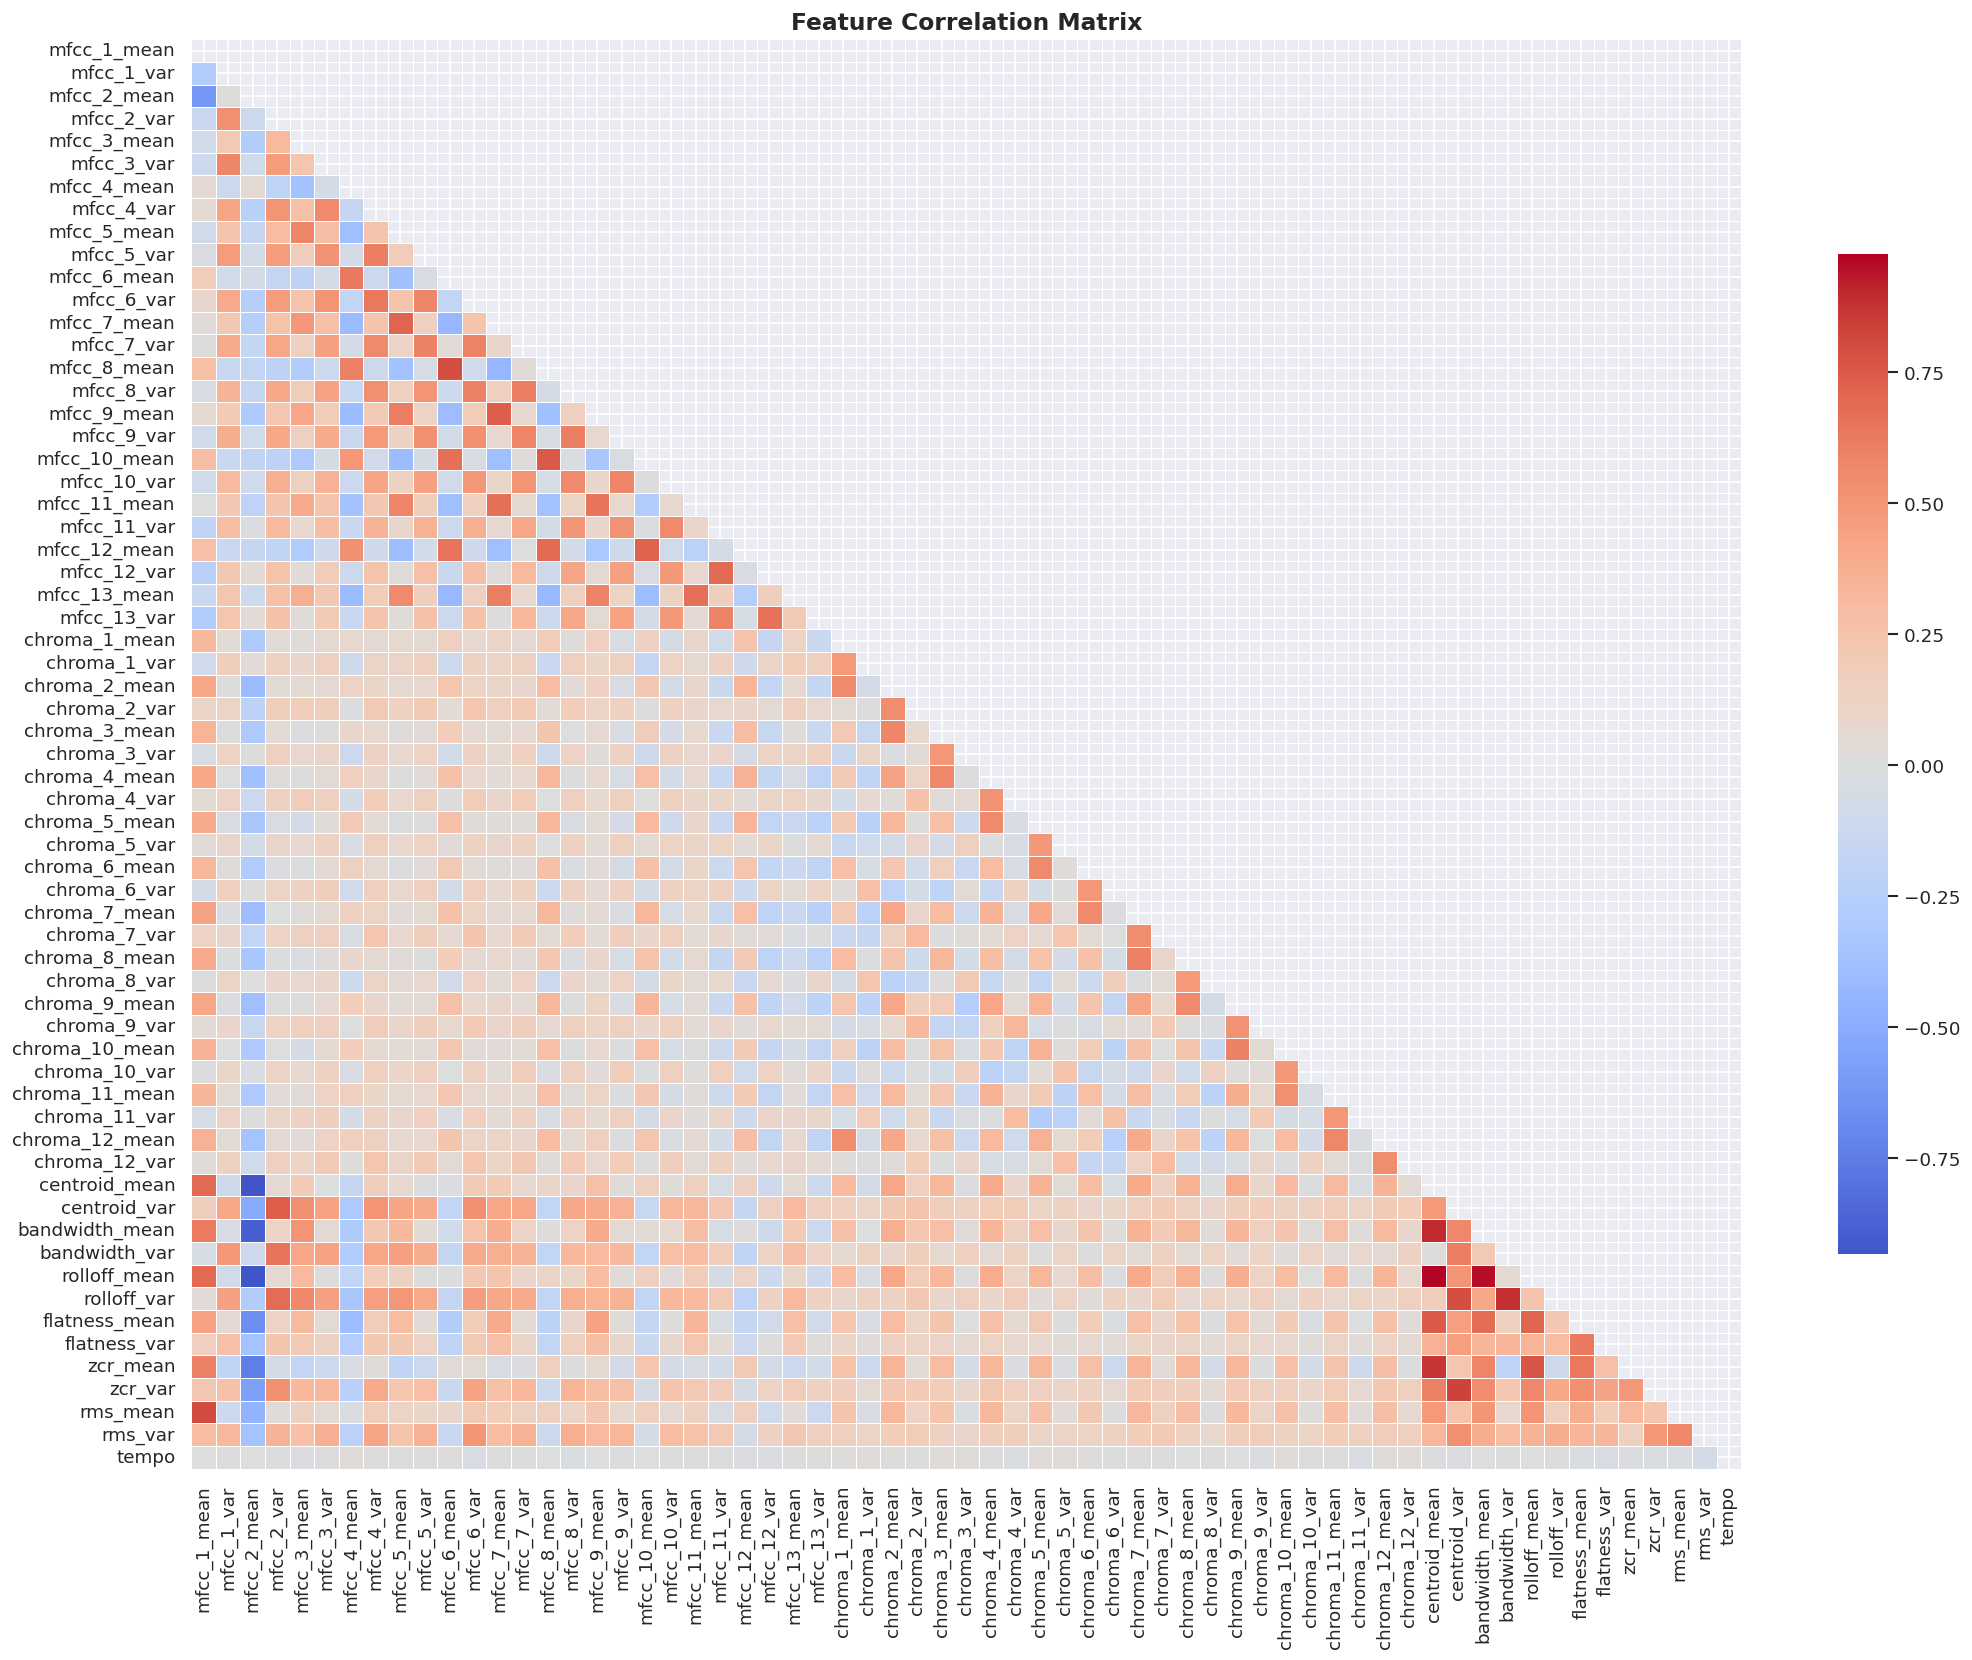

In [7]:
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0,
    linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.7}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=150)
plt.show()

## 7. PCA — 2D Visualization of Genre Separability

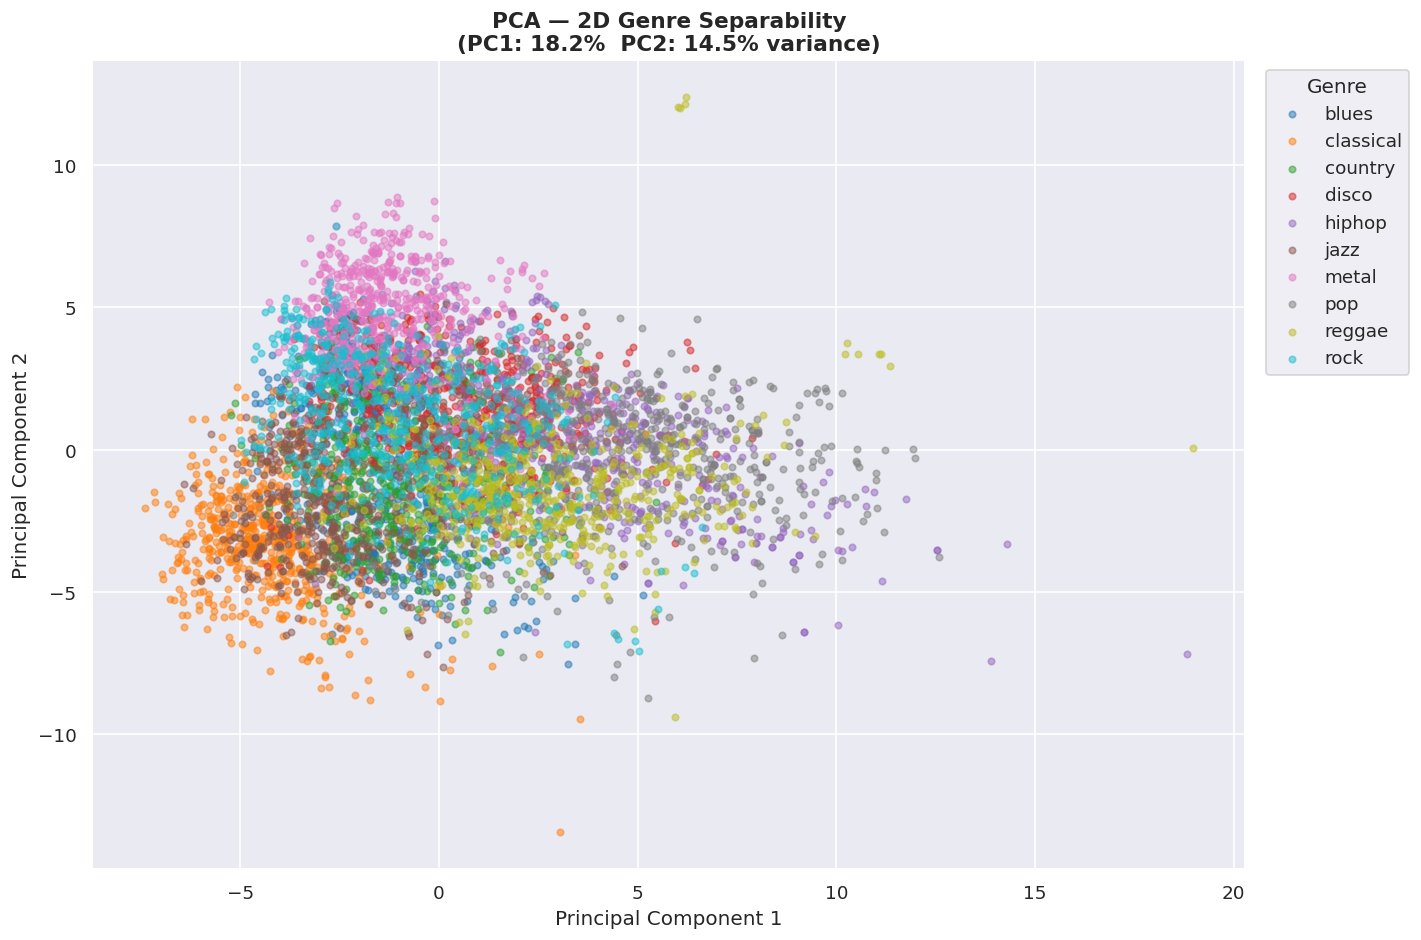

Total variance explained: 32.7%


In [8]:
X = df[feature_cols].values
y = df['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['genre'] = y

fig, ax = plt.subplots(figsize=(12, 8))
genres = sorted(pca_df['genre'].unique())
palette = sns.color_palette('tab10', len(genres))

for genre, color in zip(genres, palette):
    subset = pca_df[pca_df['genre'] == genre]
    ax.scatter(subset['PC1'], subset['PC2'], label=genre,
               color=color, alpha=0.5, s=15)

ax.set_title(
    f'PCA — 2D Genre Separability\n'
    f'(PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  '
    f'PC2: {pca.explained_variance_ratio_[1]*100:.1f}% variance)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(title='Genre', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%')

## 8. K-Means Clustering (Unsupervised Validation)

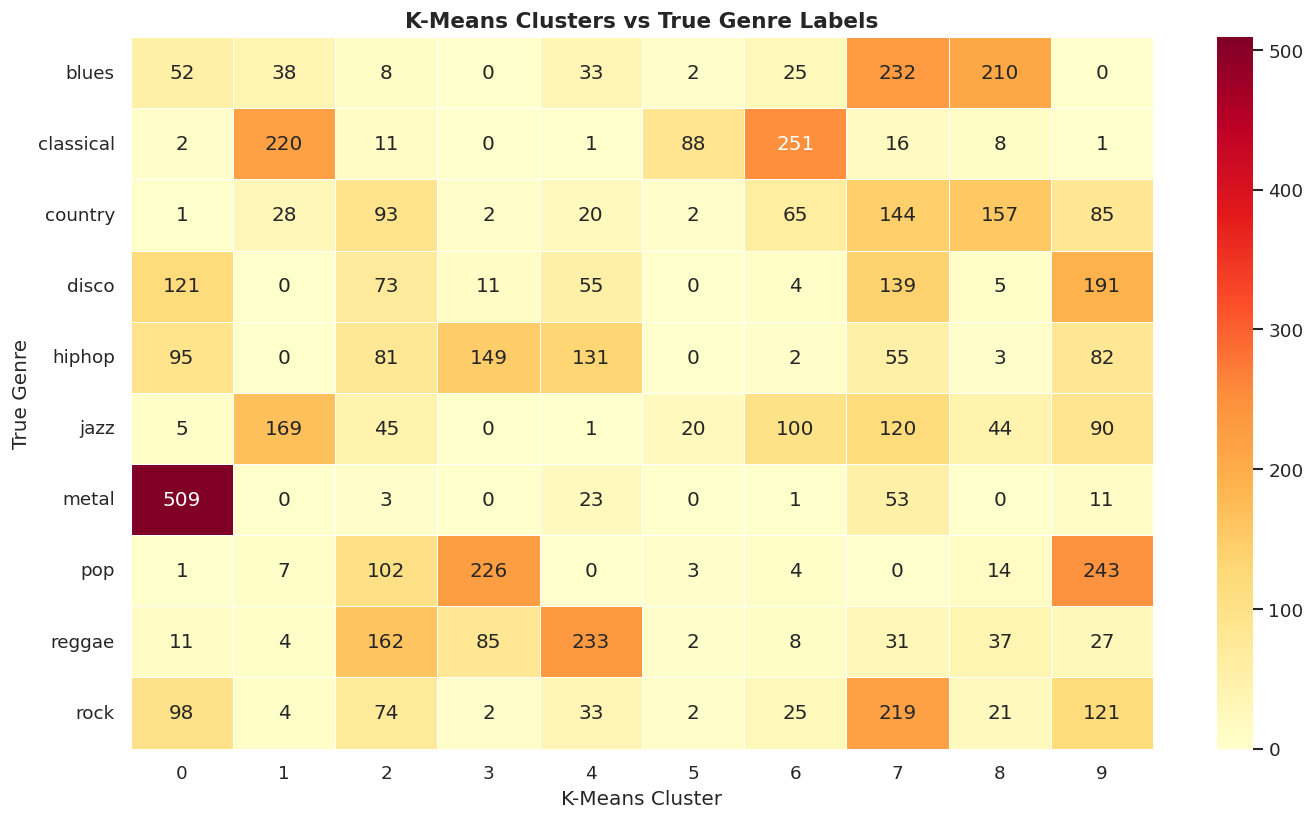

K-Means Cluster    0    1    2    3    4   5    6    7    8    9
True Genre                                                      
blues             52   38    8    0   33   2   25  232  210    0
classical          2  220   11    0    1  88  251   16    8    1
country            1   28   93    2   20   2   65  144  157   85
disco            121    0   73   11   55   0    4  139    5  191
hiphop            95    0   81  149  131   0    2   55    3   82
jazz               5  169   45    0    1  20  100  120   44   90
metal            509    0    3    0   23   0    1   53    0   11
pop                1    7  102  226    0   3    4    0   14  243
reggae            11    4  162   85  233   2    8   31   37   27
rock              98    4   74    2   33   2   25  219   21  121


In [9]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

cross_tab = pd.crosstab(
    df['label'], df['cluster'],
    rownames=['True Genre'], colnames=['K-Means Cluster']
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('K-Means Clusters vs True Genre Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_kmeans.png', dpi=150)
plt.show()

print(cross_tab)

## 9. Model Training — XGBoost

In [10]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Group split by track_id to prevent data leakage
unique_tracks = df['track_id'].unique()
train_tracks, test_tracks = train_test_split(unique_tracks, test_size=0.2, random_state=42)

train_idx = df['track_id'].isin(train_tracks)
test_idx  = df['track_id'].isin(test_tracks)

X_train = scaler.fit_transform(X[train_idx])
X_test  = scaler.transform(X[test_idx])
y_train = y_enc[train_idx]
y_test  = y_enc[test_idx]

model = XGBClassifier(
    n_estimators=500, max_depth=8,
    learning_rate=0.03, subsample=0.8,
    colsample_bytree=0.8, eval_metric='mlogloss',
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')

Accuracy: 73.62%


## 10. Confusion Matrix

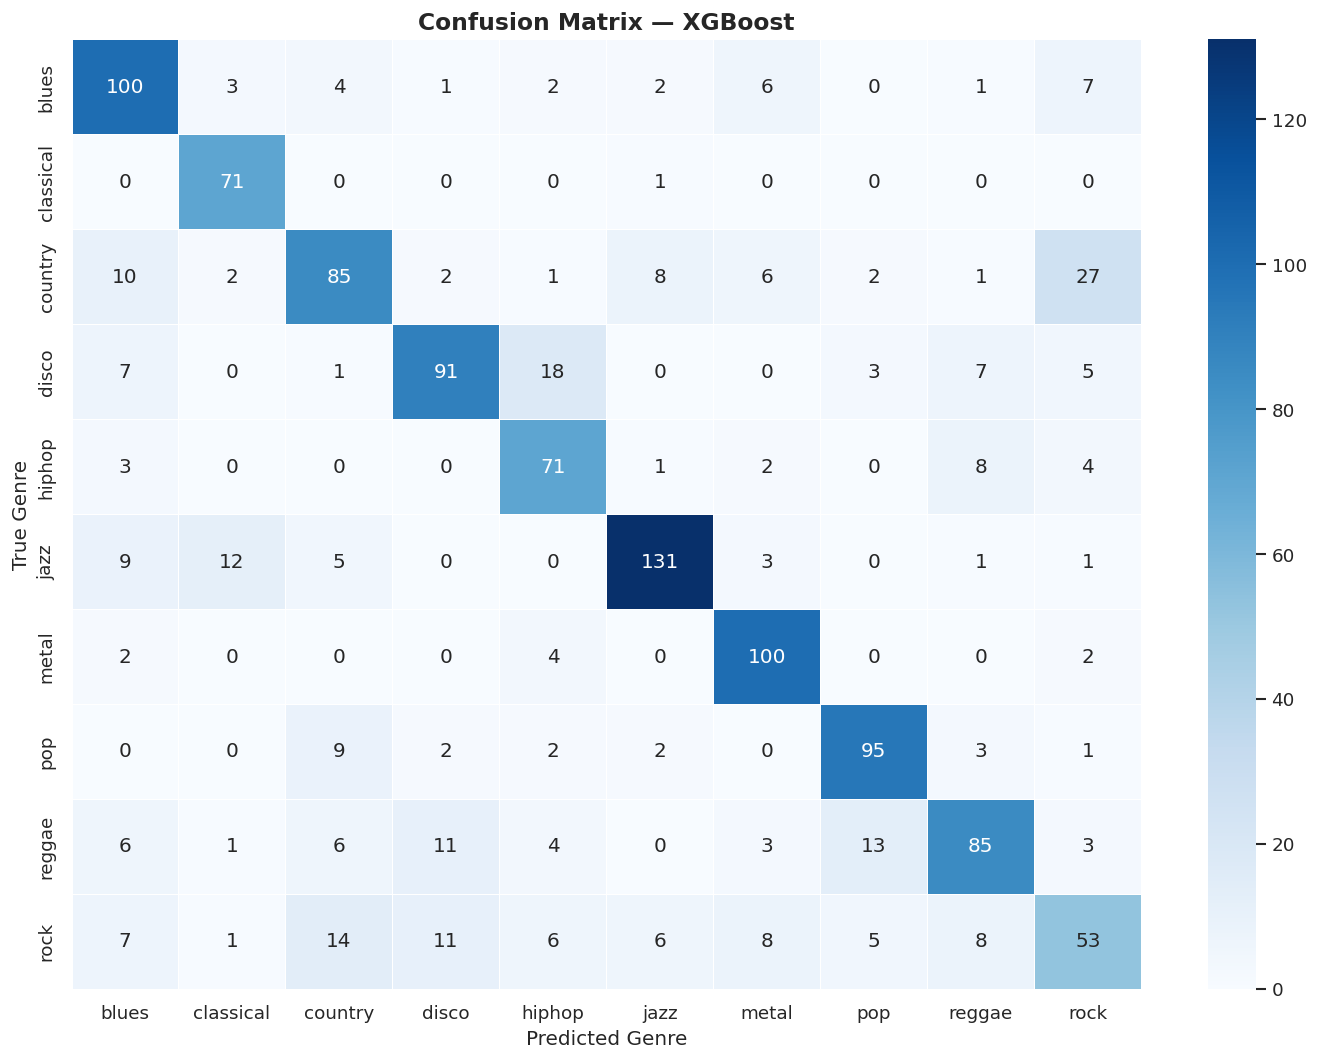

In [11]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm_df, annot=True, fmt='d', cmap='Blues',
    linewidths=0.5, ax=ax
)
ax.set_title('Confusion Matrix — XGBoost', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Genre')
ax.set_ylabel('True Genre')
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=150)
plt.show()

## 11. Classification Report

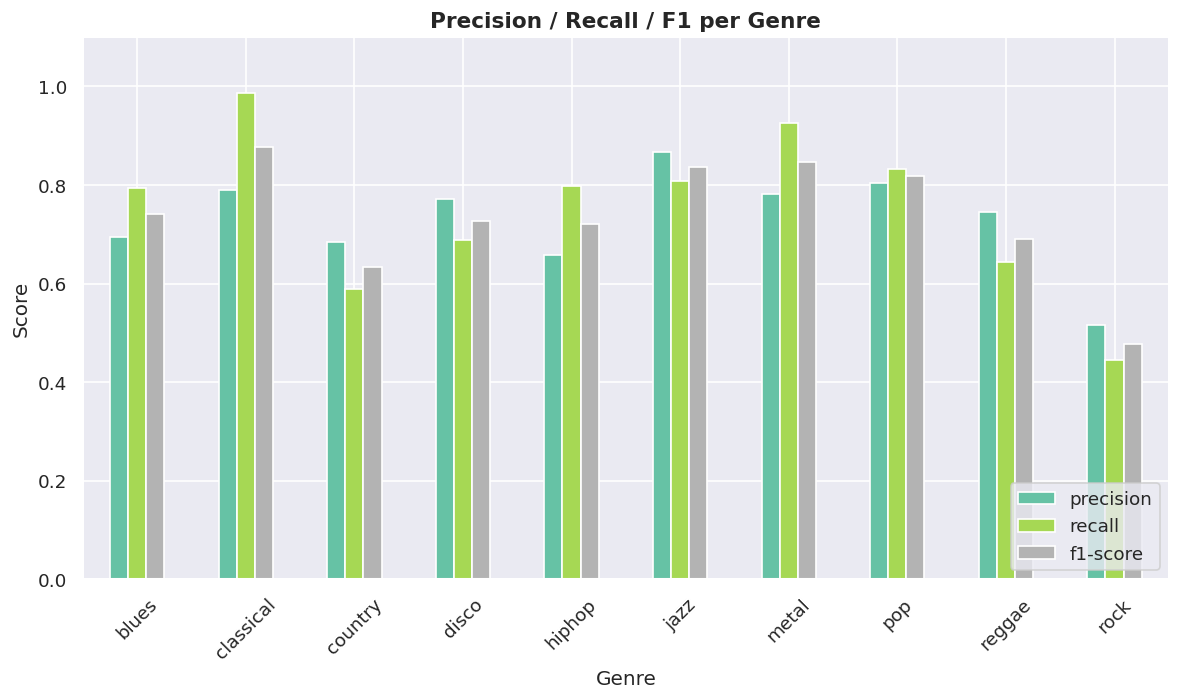

              precision    recall  f1-score   support

       blues       0.69      0.79      0.74       126
   classical       0.79      0.99      0.88        72
     country       0.69      0.59      0.63       144
       disco       0.77      0.69      0.73       132
      hiphop       0.66      0.80      0.72        89
        jazz       0.87      0.81      0.84       162
       metal       0.78      0.93      0.85       108
         pop       0.81      0.83      0.82       114
      reggae       0.75      0.64      0.69       132
        rock       0.51      0.45      0.48       119

    accuracy                           0.74      1198
   macro avg       0.73      0.75      0.74      1198
weighted avg       0.73      0.74      0.73      1198



In [12]:
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).T.drop(['accuracy', 'macro avg', 'weighted avg'])
report_df = report_df[['precision', 'recall', 'f1-score']].astype(float).round(3)

fig, ax = plt.subplots(figsize=(10, 6))
report_df.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Precision / Recall / F1 per Genre', fontsize=13, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('plot_classification_report.png', dpi=150)
plt.show()

print(classification_report(y_test, y_pred, target_names=le.classes_))

## 12. Feature Importance

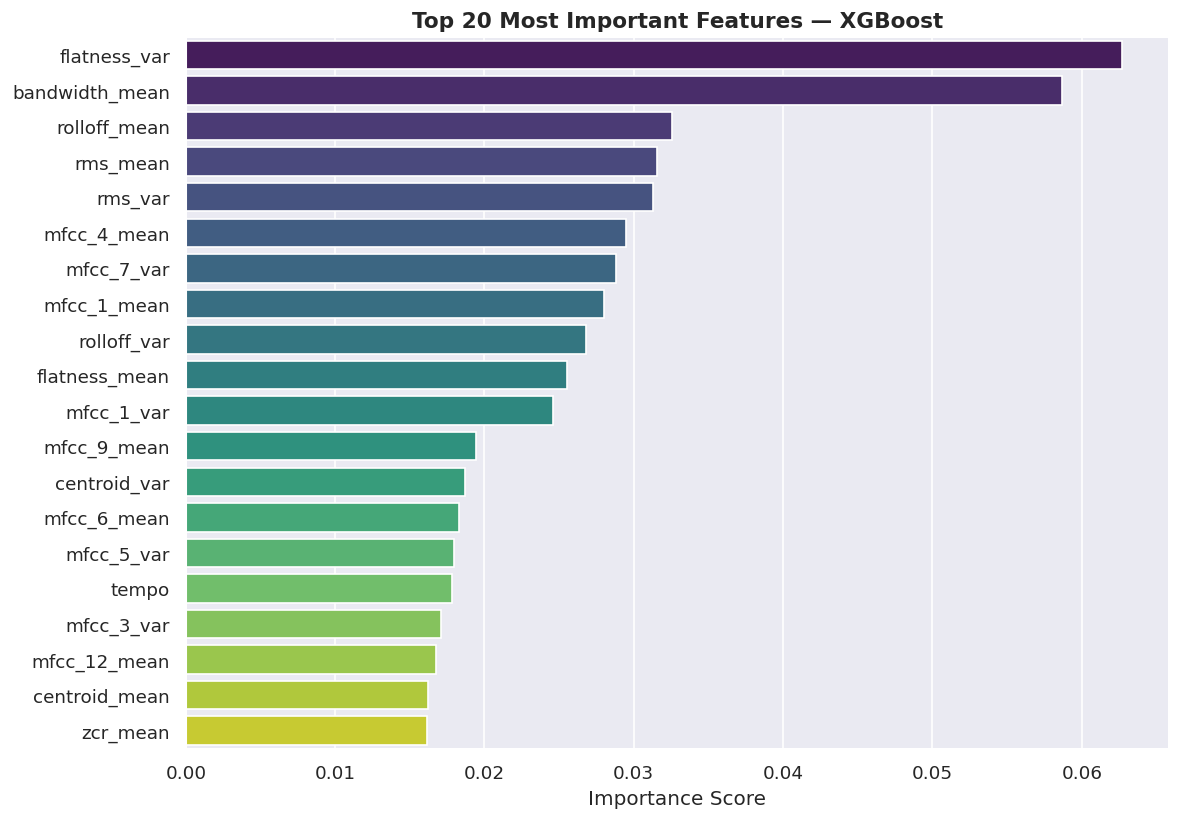

In [13]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=importance_df, y='feature', x='importance',
    palette='viridis', ax=ax
)
ax.set_title('Top 20 Most Important Features — XGBoost', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150)
plt.show()